In [8]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics
import scripts.algorithms

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)
importlib.reload(scripts.algorithms)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
dsetname = "productivity"
dsetnamex = "Productivity"
d = 11

######
graphsx = np.load("../graphs/"+dsetname+"_knn_random.npy", allow_pickle=True)


## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/productivity_knn_graphsummary.npy")
randomgraphsinfo


,Dataset (d),kmax,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Productivity (11),1,112,32,24,8,1.0,0.687500,0.312500,3.500000,0.040701,0.023488,0.017214,77,35,0,0,0
1,Productivity (11),2,112,44,33,11,2.0,1.455357,0.544643,5.090909,0.142375,0.096525,0.045849,62,11,0,0,1
2,Productivity (11),3,112,45,34,11,3.0,2.285714,0.714286,7.466667,0.294884,0.219916,0.074968,52,0,0,0,2
3,Productivity (11),4,112,46,35,11,4.0,2.946429,1.053571,9.739130,0.485199,0.335425,0.149775,28,0,0,0,3
4,Productivity (11),5,112,48,37,11,5.0,3.669643,1.330357,11.666667,0.738095,0.511422,0.226673,16,0,0,0,4
5,Productivity (11),6,112,48,37,11,6.0,4.401786,1.598214,14.000000,1.028958,0.712838,0.316120,9,0,0,0,5
6,Productivity (11),7,112,48,37,11,7.0,5.178571,1.821429,16.333333,1.351190,0.953668,0.397523,4,0,0,0,6
7,Productivity (11),8,112,48,37,11,8.0,6.017857,1.982143,18.666667,1.734878,1.267696,0.467181,3,0,0,0,7
8,Productivity (11),9,112,48,37,11,9.0,6.857143,2.142857,21.000000,2.141248,1.598295,0.542954,3,0,0,0,8
9,Productivity (11),10,112,48,37,11,10.0,7.642857,2.357143,23.333333,2.607143,1.949807,0.657336,2,0,0,0,9


## Learning

In [4]:
summary_dfx = scripts.algorithms.learn_greedy(datagraphs=graphsx, 
                                               dim=d,
                                               savedname=dsetname,
                                               thresh=False)

summary_dfx.to_csv("./ls_results/"+dsetname+"_learn_results_knn.csv", index=False)
summary_dfx.head(10)

,K,dataset,graphid,kmax,n,m,tr_utility,ts_utility,tr_size,ts_size,...,ts_only-Ns,tr_empty_adj,ts_empty_adj,tr_perf1,ts_perf1,tr_perf2,ts_perf2,tr_perf3,ts_perf3,greedyTime
0,1,productivity (11),0,1,112,32,53.450,23.550,78.0,34.0,...,10.45,0.0,0.0,100.00000,100.00000,68.52589,69.26473,0.00000,0.00000,0.011729
1,2,productivity (11),0,1,112,32,53.450,23.550,78.0,34.0,...,10.45,0.0,0.0,100.00000,100.00000,68.52589,69.26473,0.00000,0.00000,0.012187
2,3,productivity (11),0,1,112,32,53.450,23.550,78.0,34.0,...,10.45,0.0,0.0,100.00000,100.00000,68.52589,69.26473,0.00000,0.00000,0.012672
3,4,productivity (11),0,1,112,32,53.450,23.550,78.0,34.0,...,10.45,0.0,0.0,100.00000,100.00000,68.52589,69.26473,0.00000,0.00000,0.012077
4,5,productivity (11),0,1,112,32,53.450,23.550,78.0,34.0,...,10.45,0.0,0.0,100.00000,100.00000,68.52589,69.26473,0.00000,0.00000,0.012128
5,1,productivity (11),1,2,112,44,60.580,25.905,78.0,34.0,...,3.29,0.0,0.0,86.19047,84.37581,77.66656,76.19119,64.53307,58.53321,0.019476
6,2,productivity (11),1,2,112,44,63.695,27.520,78.0,34.0,...,3.29,0.0,0.0,90.61915,89.63414,81.66001,80.94122,75.85933,72.68271,0.038225
7,3,productivity (11),1,2,112,44,65.495,28.090,78.0,34.0,...,3.29,0.0,0.0,93.18074,91.47581,83.96766,82.61769,82.44834,77.32561,0.057199
8,4,productivity (11),1,2,112,44,66.750,28.365,78.0,34.0,...,3.29,0.0,0.0,94.96543,92.37712,85.57665,83.42649,87.04724,79.74771,0.073942
9,5,productivity (11),1,2,112,44,67.730,28.645,78.0,34.0,...,3.29,0.0,0.0,96.36044,93.28958,86.83320,84.25005,90.65166,82.17063,0.092923


## Plots

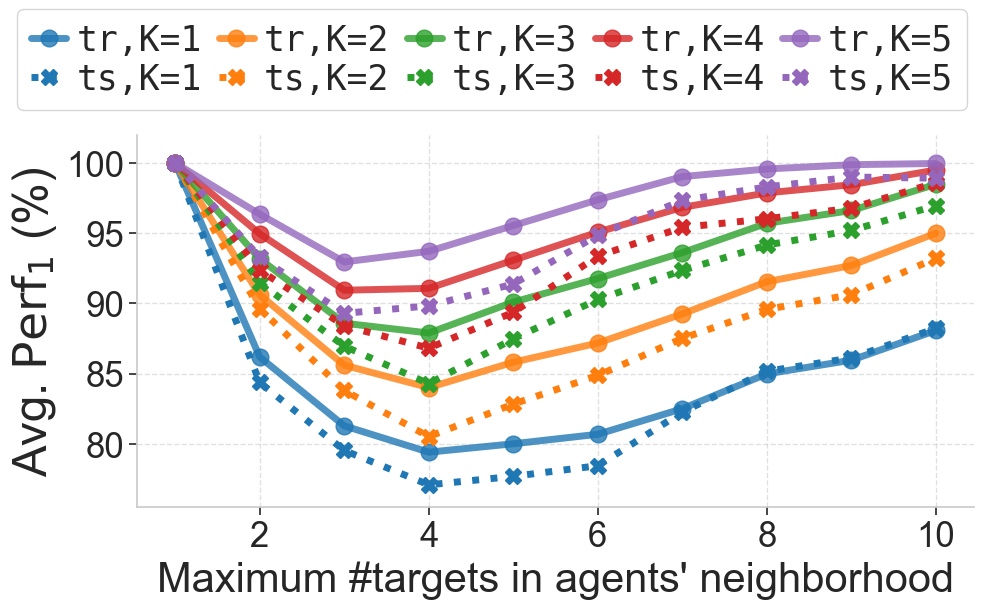

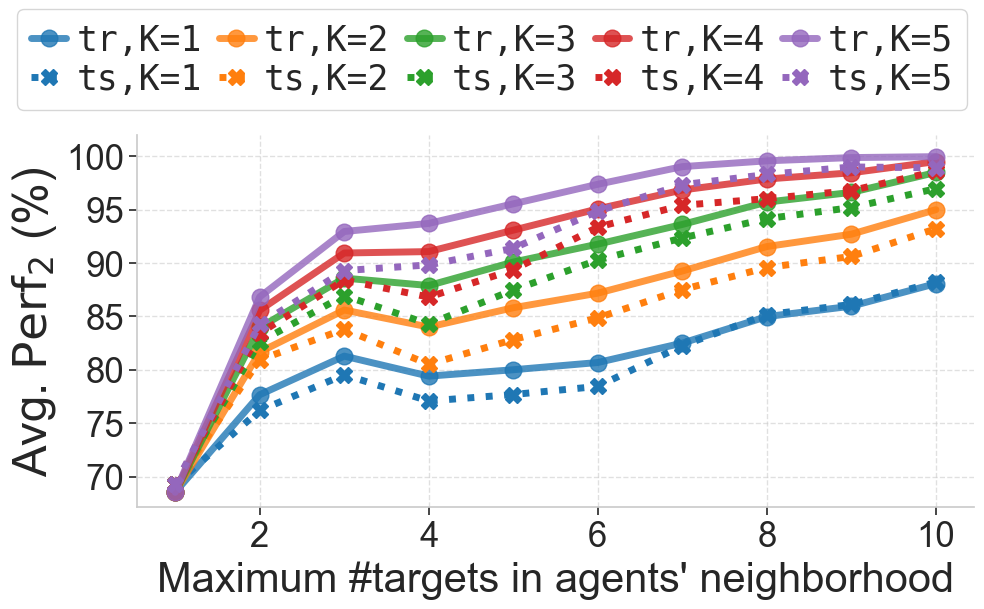

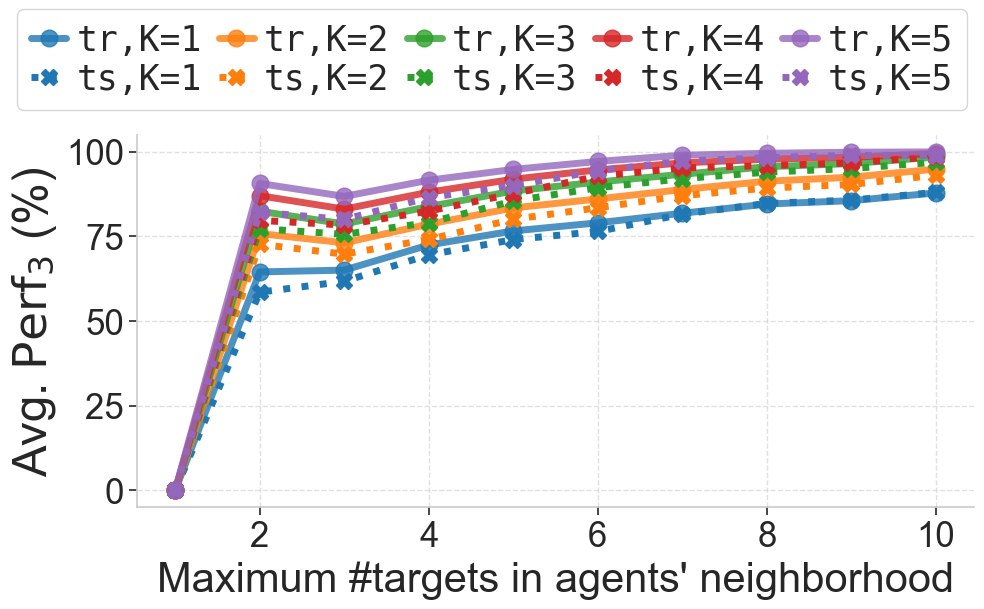

In [9]:
######### exclude: no neighbors and exclusively neg neighbors
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=False, 
                  perfv="perf1", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_knn_perf1.pdf")

######### exclude: none
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=False, 
                  perfv="perf2", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_knn_perf2.pdf")

######### exclude: no neighbors and exclusively neg/pos neighbors
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=False, 
                  perfv="perf3", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_knn_perf3.pdf")

